## Building an Object-Detection Training Set from Videos

This demo turns raw videos into a pytorch-ready object-detection training set, using a declarative
Pixeltable schema. The pipeline is a three-level table hierarchy:

```
videos (table)             source videos + metadata
  -> frames (view)         one frame per second (frame_iterator), YOLOX detections as pseudo-labels
  -> training_frames       frames with detections, resized to 640x640, boxes rescaled to match
     (view)
```

Everything downstream of `videos` is computed automatically and incrementally: insert a video, get
training samples.

Requirements: `pip install -U pixeltable pixeltable-yolox torch torchvision`


In [1]:
# %pip install -qU pixeltable pixeltable-yolox torch torchvision


### The schema

The whole pipeline lives in a single file, `schema.py` (shown below): a class-based schema with one
class per table/view, columns as annotations, and computed columns as assignments. We register it from
the command line with `pxt schema update`, which creates any tables that don't exist yet. Two details
worth calling out:

- `frame` and the `overlay` columns are **unstored**: they are computed on demand (frames are
  re-extracted from the video when read), so no image data is persisted.
- the box math (`bboxes_resize_canvas`) and visualization (`bboxes_draw`) are Pixeltable built-ins;
  the image and its boxes are transformed together, so they cannot drift apart.

In [3]:
print(open('schema.py').read())

"""Class-based Pixeltable schema for building an object-detection training set from videos.

Hierarchy:
    videos (table)            source videos + metadata
    -> frames (view)          one row per extracted frame (frame_iterator, 1 fps), YOLOX detections
    -> training_frames (view) frames with at least one detection, resized to the model input size,
                              with bounding boxes rescaled to match

Create or update the schema with:
    pxt schema update schema.py od_demo
"""

import pixeltable as pxt
import pixeltable.functions as pxtf
from pixeltable.catalog.model import Column

TableModel = pxt.model_base()

# model input size (square); boxes are rescaled to this canvas
IMG_SIZE = 640


class Videos(TableModel, name='videos'):
    """Source videos; insert local files or s3/http URLs."""

    video: pxt.Required[pxt.Video]
    metadata = pxtf.video.get_metadata(video)  # noqa: F821


class Frames(TableModel, name='frames', base=Videos, iterator=pxtf.video.fram

In [4]:
!pxt schema update schema.py od_demo


Connected to Pixeltable database at: postgresql+psycopg://postgres:@/pixeltable?host=/home/marcel/.pixeltable/pgdata
exists   od_demo/videos
exists   od_demo/frames
exists   od_demo/training_frames


In [5]:
import pixeltable as pxt

videos = pxt.get_table('od_demo.videos')
frames = pxt.get_table('od_demo.frames')
training_frames = pxt.get_table('od_demo.training_frames')


Connected to Pixeltable database at: postgresql+psycopg://postgres:@/pixeltable?host=/home/marcel/.pixeltable/pgdata


### Insert videos

We use a handful of public videos from the
[Multimedia Commons](http://mmcommons.org/) S3 bucket (no credentials needed). Inserting them runs the
entire pipeline: frame extraction, YOLOX inference, and training-sample construction.


In [6]:
S3_PREFIX = 's3://multimedia-commons/data/videos/mp4/'
video_paths = [
    '9cd/047/9cd047335f12962a5e633c3b9e6602e.mp4',
    '111/015/1110153dc81d833025828f875b3ad2.mp4',
    '888/061/8880616a157cfd9036fc16ad6cf5c3af.mp4',
    'abc/01a/abc01aa533364ca1597e0f287f393b9.mp4',
    '00a/a5b/00aa5b8cc17f67eded6a257a61119.mp4',
    '7ab/023/7ab02326a7c9ab4728681f63aaa7c36d.mp4',
]
videos.insert([{"video": S3_PREFIX + p} for p in video_paths])
print(f'{videos.count()} videos -> {frames.count()} frames -> {training_frames.count()} training samples')

Inserted 516 rows with 0 errors in 19.79 s (26.08 rows/s)
13 videos -> 580 frames -> 580 training samples


In [7]:
videos.count()

13

### Inspect the pseudo-labels

The `overlay` column renders the YOLOX detections on the frame. It is unstored: the image below is
produced at query time (the same column can be browsed in the dashboard). `num_detections` is a
computed column defined as `detections.bboxes.len()`, using the built-in `len()` JSON method.

overlay,num_detections,detections
,10,"{""bboxes"": [[578.175, -0.025, 639.806, 266.715], [374.737, 92.543, 502.115, 330.198], [296.311, -0.442, 387.405, 161.159], [466.705, 0.721, 566.306, 246.916], [0.241, 176.022, 148.741, 356.334], [381.892, 1.608, 473.251, 145.727], [231.457, 8.796, 304.812, 181.005], [169.852, 99.692, 354.036, 355.986], [317.919, 115.979, 383.53, 280.221], [530.029, 78.477, 569.64, 166.639]], ""labels"": [0, 0, 0, 0, 0, 0, 0, 0, 0, 26], ""scores"": [0.864, 0.858, 0.833, 0.77, 0.741, 0.696, 0.67, 0.658, 0.547, 0.538]}"
,11,"{""bboxes"": [[370.876, 85.917, 504.347, 327.072], [567.533, -6.385, 640.443, 260.055], [173.097, 97.126, 346.975, 359.333], [293.399, 0.194, 385.037, 156.019], [469.945, -2.044, 570.633, 216.973], [166.172, 0.484, 237.149, 150.209], [4.141, 71.85, 273.809, 356.799], [80.145, -4.543, 175.543, 183.792], [383.608, -0.634, 478.471, 156.045], [232.285, 6.404, 301.584, 160.443], [321.54, 110.845, 381.208, 306.741]], ""labels"": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], ""scores"": [0.87, 0.868, 0.857, 0.814, 0.774, 0.682, 0.67, 0.637, 0.629, 0.612, 0.605]}"

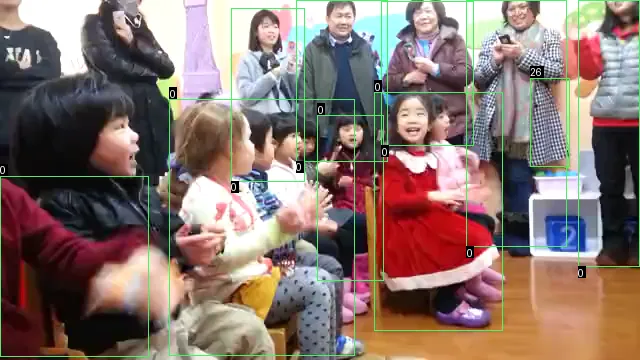
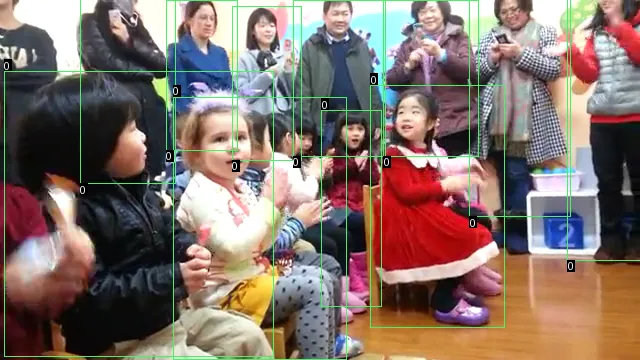

In [8]:
frames.select(frames.overlay, frames.num_detections, frames.detections).show(2)

### Incremental computation

Insert one more video: only its frames are processed, everything already computed stays untouched.


In [9]:
videos.insert([{'video': S3_PREFIX + 'cde/078/cde078a6803a16cae79eb438e178f0ce.mp4'}])
print(f'{videos.count()} videos -> {frames.count()} frames -> {training_frames.count()} training samples')


Inserted 141 rows with 0 errors in 5.13 s (27.51 rows/s)
14 videos -> 650 frames -> 650 training samples


### Image transforms for detection training

Object-detection training uses two kinds of transforms, and they belong in different places:

| | examples | where |
|---|---|---|
| **deterministic preprocessing** | decode, resize/letterbox to model input size, rescale boxes, drop degenerate boxes, coordinate-format conversion | Pixeltable computed columns: computed once, cached, versioned, shared |
| **stochastic augmentation** | random flip, scale jitter, random crop, mosaic/mixup, color jitter, random erasing | the training DataLoader: must differ every epoch, so it is never materialized |

Geometric augmentations must transform the boxes along with the image - use
`torchvision.transforms.v2` with `tv_tensors.BoundingBoxes` (or albumentations with `bbox_params`).

The `training_frames` view holds the deterministic part: 640x640 images with boxes rescaled to match.
Its `overlay` column lets us verify the two stayed consistent:


overlay,labels
,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 26]"
,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"

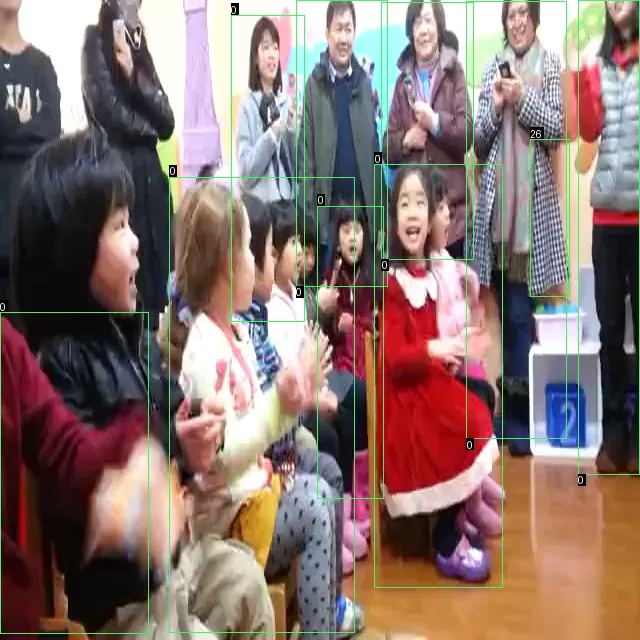
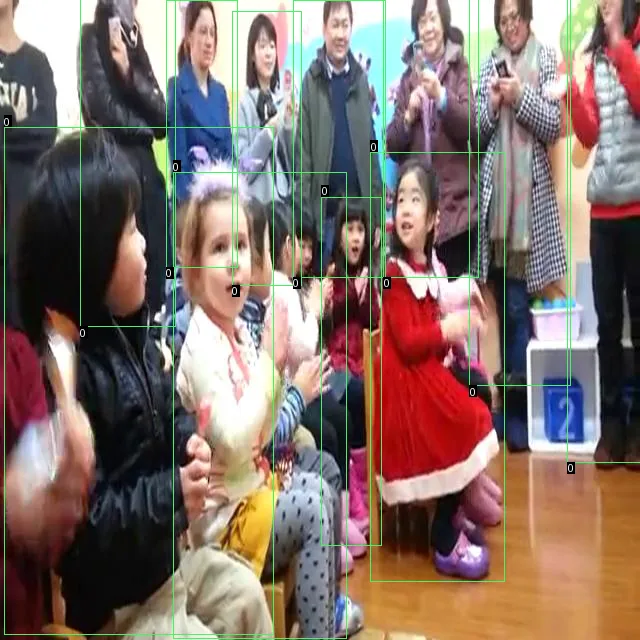

In [10]:
training_frames.select(training_frames.overlay, training_frames.labels).show(2)


### Export to pytorch

`to_pytorch_dataset()` serializes the query result to a disk cache once and returns an
`IterableDataset`; re-running epochs reads from the cache instead of re-executing the query.
With `image_format='pt'`, images arrive as CxHxW float32 tensors in [0, 1].

The custom `collate_fn` is needed because each sample has a different number of boxes; it is also the
natural home for the stochastic augmentations.


In [11]:
import torch
from torch.utils.data import DataLoader
from torchvision import tv_tensors
from torchvision.transforms import v2

dataset = training_frames.select(
    training_frames.image, training_frames.boxes, training_frames.labels
).to_pytorch_dataset(image_format='pt')

In [12]:
dataset

In [13]:
augment = v2.RandomHorizontalFlip(p=0.5)

def collate(samples: list[dict]) -> dict:
    images, boxes, labels = [], [], []
    for s in samples:
        bb = tv_tensors.BoundingBoxes(
            torch.tensor(s['boxes'], dtype=torch.float32), format='XYXY', canvas_size=(640, 640)
        )
        img, bb = augment(s['image'], bb)
        images.append(img)
        boxes.append(torch.as_tensor(bb))
        labels.append(torch.tensor(s['labels'], dtype=torch.int64))
    return {'images': torch.stack(images), 'boxes': boxes, 'labels': labels}

loader = DataLoader(dataset, batch_size=8, collate_fn=collate)
batch = next(iter(loader))
print('images:', batch['images'].shape, batch['images'].dtype)
print('boxes[0]: ', batch['boxes'][0].shape)
print('labels[0]:', batch['labels'][0].shape)

images: torch.Size([8, 3, 640, 640]) torch.float32
boxes[0]:  torch.Size([10, 4])
labels[0]: torch.Size([10])


### Where to go from here

- `to_coco_dataset()` exports the same data as a COCO json for other tooling.
- An embedding index on `frames.frame` turns curation into a query: find more frames like a hard example.
- Label with a larger model (`yolox_x`) and evaluate a smaller one against it with
  `pxtf.vision.eval_detections()` + `mean_ap()` - a two-computed-column eval harness.
